# DS207 Final Project - Predicting Readmission Rate for Diabetic Patients Using Machine Learning
#### Contributor: Colin Frishberg (cpfrish@berkeley.edu)

### Notebook Structure:

1.  Create compelling **data visualizations**.
2.  **Input:** Load raw and processed data from data files.
3.  Build, train, and evaluate the **Transformer Model**.
4.  **Output:** Save the visualizations to html files in the '/results' directory
5.  **Output:** Save the trained Transformer model to `/results/transformer.h5`.
6.  **Output:** Save the statistics from the transformer model to `/results/stats_transformer.csv`.

## 1. Notebook Imports

### 1.1 Import basic and necessary libraries:

In [1]:
# Basic imports
import numpy as np
import warnings
import pandas as pd
import tensorflow as tf
from matplotlib import pyplot as plt
from tensorflow import keras
import altair as alt

# SMOTE for handling class imbalance
from imblearn.over_sampling import SMOTE

alt.data_transformers.enable("vegafusion")

# Compress all warnings
warnings.filterwarnings("ignore")


2025-12-08 12:29:42.727125: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-08 12:29:42.727402: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-08 12:29:42.761221: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-08 12:29:43.754977: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

### 1.2 Import datasets:

In [2]:
# Load raw data set
df = pd.read_csv("../data/diabetic_data.csv")


# Load train, val, test splits (from Rahil's notebook)
df_train = pd.read_csv("../results/train.csv")
df_val = pd.read_csv("../results/val.csv")
df_test = pd.read_csv("../results/test.csv")

# Load colin_final data splits with SHAP-refined features (for model development)
# Using TRANSFORMED data with reduced skewness/kurtosis
X_train_final_selected = pd.read_csv("../data/X_train_final_selected_transformed.csv")
X_val_final_selected = pd.read_csv("../data/X_val_final_selected_transformed.csv")
X_test_final_selected = pd.read_csv("../data/X_test_final_selected_transformed.csv")
Y_train_final = pd.read_csv("../data/y_train.csv")
Y_val_final = pd.read_csv("../data/y_val.csv")
Y_test_final = pd.read_csv("../data/y_test.csv")

# Combine train, val, test into a single dataframe for visualization
df_combined_final = pd.concat([X_train_final_selected, X_val_final_selected, X_test_final_selected], axis=0)

print("=" * 70)
print("DATA LOADING SUMMARY")
print("=" * 70)
print(f"Using TRANSFORMED data (Yeo-Johnson power transform)")
print(f"  - Reduced skewness and kurtosis")
print(f"  - Optimized for neural network training")
print("=" * 70)

DATA LOADING SUMMARY
Using TRANSFORMED data (Yeo-Johnson power transform)
  - Reduced skewness and kurtosis
  - Optimized for neural network training


In [3]:
# Display shape of raw and cleaned data sets
print(f"Raw data set shape: {df.shape}")
print(f"Train split shape: {df_train.shape}")
print(f"Validation split shape: {df_val.shape}")
print(f"Test split shape: {df_test.shape}")
print(f"\nFinal selected features (SHAP-refined + TRANSFORMED):")
print(f"X_train shape: {X_train_final_selected.shape}")
print(f"X_val shape: {X_val_final_selected.shape}")
print(f"X_test shape: {X_test_final_selected.shape}")
print(f"\nCombined final shape: {df_combined_final.shape}")
print(f"\nTransformation: Yeo-Johnson power transform applied")
print(f"  → Reduced skewness and kurtosis for better model training")

Raw data set shape: (101766, 50)
Train split shape: (42910, 43)
Validation split shape: (14304, 43)
Test split shape: (14304, 43)

Final selected features (SHAP-refined + TRANSFORMED):
X_train shape: (40251, 25)
X_val shape: (13417, 25)
X_test shape: (13418, 25)

Combined final shape: (67086, 25)

Transformation: Yeo-Johnson power transform applied
  → Reduced skewness and kurtosis for better model training


In [4]:
# Check class distribution before SMOTE
print("=" * 70)
print("CLASS DISTRIBUTION BEFORE SMOTE")
print("=" * 70)
print(f"Training set:")
y_train_values = Y_train_final.values.ravel()
unique, counts = np.unique(y_train_values, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  Class {label}: {count} ({count/len(y_train_values)*100:.2f}%)")
print(f"  Total samples: {len(y_train_values)}")
print(f"  Imbalance ratio: {counts[0]/counts[1]:.2f}:1")

# Apply SMOTE to training data only
# Note: We only apply SMOTE to training data, never to validation or test sets
print(f"\n{'='*70}")
print("APPLYING SMOTE TO TRAINING DATA")
print(f"{'='*70}")

smote = SMOTE(random_state=1234, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_final_selected, 
    y_train_values
)

# Convert back to DataFrame to maintain column names
X_train_smote = pd.DataFrame(
    X_train_smote, 
    columns=X_train_final_selected.columns
)

print(f"\nClass distribution after SMOTE:")
unique, counts = np.unique(y_train_smote, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  Class {label}: {count} ({count/len(y_train_smote)*100:.2f}%)")
print(f"  Total samples: {len(y_train_smote)}")
print(f"  Imbalance ratio: 1:1 (balanced)")

print(f"\n{'='*70}")
print("SMOTE SUMMARY")
print(f"{'='*70}")
print(f"Original training samples: {len(y_train_values)}")
print(f"Augmented training samples: {len(y_train_smote)}")
print(f"Synthetic samples created: {len(y_train_smote) - len(y_train_values)}")
print(f"\nValidation and test sets remain unchanged (no SMOTE applied)")
print(f"{'='*70}")

# Update the training data variables to use SMOTE versions
X_train_final_selected_original = X_train_final_selected.copy()
Y_train_final_original = Y_train_final.copy()

X_train_final_selected = X_train_smote
Y_train_final = pd.DataFrame(y_train_smote, columns=['readmitted'])


CLASS DISTRIBUTION BEFORE SMOTE
Training set:
  Class 0: 36581 (90.88%)
  Class 1: 3670 (9.12%)
  Total samples: 40251
  Imbalance ratio: 9.97:1

APPLYING SMOTE TO TRAINING DATA

Class distribution after SMOTE:
  Class 0: 36581 (50.00%)
  Class 1: 36581 (50.00%)
  Total samples: 73162
  Imbalance ratio: 1:1 (balanced)

SMOTE SUMMARY
Original training samples: 40251
Augmented training samples: 73162
Synthetic samples created: 32911

Validation and test sets remain unchanged (no SMOTE applied)


### 1.3 Apply SMOTE to Handle Class Imbalance

## 2. Visualization

In [5]:
# Install vegafusion for Altair visualizations
# %pip install "vegafusion[embed]>=1.5.0"
# Install vl-convert-python for Altair visualizations
# %pip install "vl-convert-python>=1.6.0"

This section is broken into two parts. One being Ditributions of the data, the second being Statistical Analysis using assumptions of Logistic Regression for a Binary Classification problem.  

#### Target Variable Distribution

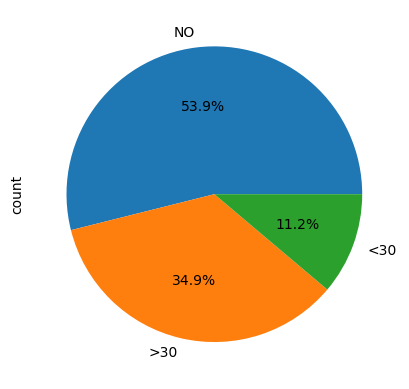

In [6]:
# Visualization of readmission distribution
df["readmitted"].value_counts() / len(df)
counts = df["readmitted"].value_counts()

percentages = counts * 100 / len(df)

fig, ax = plt.subplots()
percentages.plot(kind="pie", ax=ax, autopct="%1.1f%%")
plt.show()

In [7]:
# Define continuous features
continuous_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "age_mid",
]

#### Kernel Density Estimates plots

In [8]:
def create_kde_plots(df, kde_vars, ncols=2):
    """
    Generates and combines KDE plots into a grid for given features

    Args:
        df (pd.Dataframe)
        kde_vars(list): List of columns to plot
        ncols(int): Number of columns in the grid

    Returns:
        alt.vconcat: Grid of KDE plots
    """
    charts = []
    for var in kde_vars:
        chart = (
            alt.Chart(df)
            .transform_density(
                density=var,
                as_=[var, "Density"],  # The output fields for the value and its density
                groupby=["readmitted"],
            )
            .mark_area(opacity=0.5)
            .encode(
                x=alt.X(f"{var}:Q", title=var.replace("_", " ").title()),
                y=alt.Y("Density:Q"),
                # Color by the 'readmitted' class aka target variable
                color=alt.Color("readmitted:N", title="Readmitted Class"),
            )
            .properties(
                title=f"Distribution of {var.replace('_', ' ').title()}",
                width=300,
                height=200,
            )
        )
        charts.append(chart)

        # Grid creations
        rows = [
            alt.hconcat(*charts[i : i + ncols]) for i in range(0, len(charts), ncols)
        ]
    # Combine all created charts vertically and return them
    return alt.vconcat(*rows)

#### Box Plots

In [9]:
# Box Plots for distributions of key predictors to outcome
def create_box_plots(df, continuous_features):
    """
    Generates and combines box plots into a grid for given features

    Args:
        df (pd.Dataframe)
        continuous_features(list): List of columns to plot
    """
    box_plots = []
    for feature in continuous_features:
        # Create box plot for each feature against readmission
        chart = (
            alt.Chart(df)
            .mark_boxplot()
            .encode(
                x=alt.X(
                    "readmitted:N", title="Readmitted Class (0: NO, 1: >30, 2: <30)"
                ),
                y=alt.Y(f"{feature}:Q", title=feature.replace("_", " ").title()),
                color=alt.Color("readmitted:N", title="Readmitted Class").scale(
                    scheme="category20"
                ),
                tooltip=["readmitted", feature],
            )
            .properties(
                title=f"Box Plot of {feature.replace('_', ' ').title()} by Readmission Status",
                width=300,
                height=200,
            )
        )
        box_plots.append(chart)

    # Arrange the box plots in a grid
    ncols = 3
    rows = [
        alt.hconcat(*box_plots[i : i + ncols]) for i in range(0, len(box_plots), ncols)
    ]
    alt.vconcat(*rows)
    return alt.vconcat(*rows)

#### Violin Plots

In [10]:
def create_violin_plots(df, continuous_features):
    """
    Generates and combines violin plots into a grid for given features

    Args:
        df (pd.Dataframe)
        continuous_features(list): List of columns to plot
    """
    # Create violin plots for each continuous feature

    violin_plots = []
    for feature in continuous_features:
        chart = (
            alt.Chart(df)
            .transform_density(
                density=feature, as_=[feature, "density"], groupby=["readmitted"]
            )
            .mark_area(orient="horizontal")
            .encode(
                y=alt.Y(f"{feature}:Q", title=feature.replace("_", " ").title()),
                x=alt.X(
                    "density:Q",
                    stack="center",
                    impute=None,
                    title=None,
                    axis=alt.Axis(labels=False, values=[0], grid=False, ticks=True),
                ),
                color=alt.Color(
                    "readmitted:N", legend=alt.Legend(title="Readmitted")
                ).scale(scheme="tableau20"),
            )
            .properties(
                title=f"Distribution of {feature.replace('_', ' ').title()} by Readmission",
                width=300,
                height=250,
            )
        )
        violin_plots.append(chart)

    # Arrange the violin plots in a grid
    ncols = 4
    rows_violin = [
        alt.hconcat(*violin_plots[i : i + ncols])
        for i in range(0, len(violin_plots), ncols)
    ]
    final_violin_chart = alt.vconcat(*rows_violin)
    return final_violin_chart


## 2.1 Statistical EDA

### 2.1.1 Skewness Analysis

SKEWNESS COMPARISON: RAW vs RAHIL vs COLIN

1. Raw Data:
   Total features: 13
   Mean |skewness|: 3.581
   Highly skewed (|skew| > 1): 9
   Moderately skewed (|skew| > 0.5): 11

2. Rahil's Processed Data:
   Total features: 42
   Mean |skewness|: 33.963
   Highly skewed (|skew| > 1): 32
   Moderately skewed (|skew| > 0.5): 34

3. Colin's Final Processed Data:
   Total features: 25
   Mean |skewness|: 1.899
   Highly skewed (|skew| > 1): 15
   Moderately skewed (|skew| > 0.5): 17


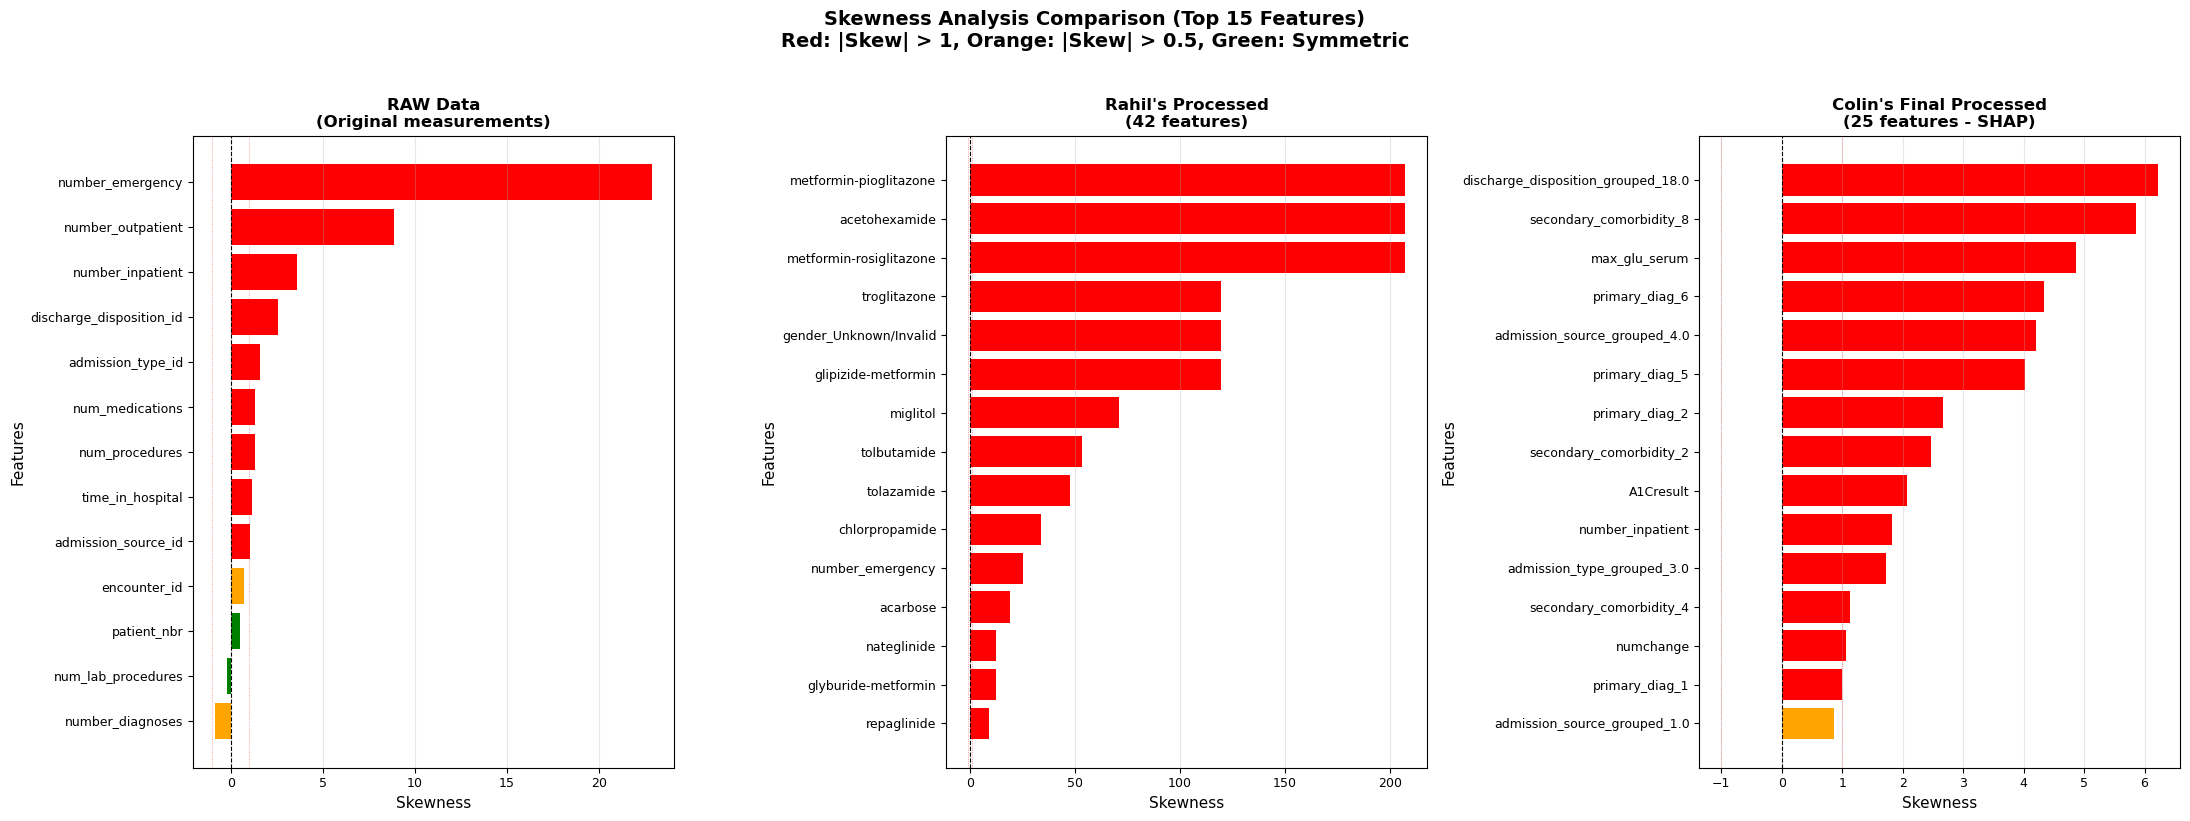

In [11]:
from scipy.stats import skew
import seaborn as sns

# Get numerical columns from raw data
raw_numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'readmitted' in raw_numerical_cols:
    raw_numerical_cols.remove('readmitted')

# Get numerical columns from Rahil's TRAINING data
rahil_numerical_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
if 'readmitted' in rahil_numerical_cols:
    rahil_numerical_cols.remove('readmitted')

# Get numerical columns from Colin's final TRAINING data
colin_numerical_cols = X_train_final_selected.select_dtypes(include=[np.number]).columns.tolist()
if 'readmitted' in colin_numerical_cols:
    colin_numerical_cols.remove('readmitted')

# Calculate skewness for RAW data
skewness_raw = []
for col in raw_numerical_cols:
    skew_value = skew(df[col].dropna())
    skewness_raw.append({'Feature': col, 'Skewness': skew_value})

skewness_raw_df = pd.DataFrame(skewness_raw).sort_values('Skewness', ascending=False)

# Calculate skewness for RAHIL's TRAINING data
skewness_rahil = []
for col in rahil_numerical_cols:
    skew_value = skew(df_train[col].dropna())
    skewness_rahil.append({'Feature': col, 'Skewness': skew_value})
skewness_rahil_df = pd.DataFrame(skewness_rahil).sort_values('Skewness', ascending=False)

# Calculate skewness for COLIN's final TRAINING data
skewness_colin = []
for col in colin_numerical_cols:
    skew_value = skew(X_train_final_selected[col].dropna())
    skewness_colin.append({'Feature': col, 'Skewness': skew_value})
skewness_colin_df = pd.DataFrame(skewness_colin).sort_values('Skewness', ascending=False)

# Comparison statistics
print("="*80)
print("SKEWNESS COMPARISON: RAW vs RAHIL vs COLIN")
print("="*80)

print(f"\n1. Raw Data:")
print(f"   Total features: {len(skewness_raw_df)}") 
print(f"   Mean |skewness|: {skewness_raw_df['Skewness'].abs().mean():.3f}")
print(f"   Highly skewed (|skew| > 1): {(skewness_raw_df['Skewness'].abs() > 1).sum()}")
print(f"   Moderately skewed (|skew| > 0.5): {(skewness_raw_df['Skewness'].abs() > 0.5).sum()}")

print(f"\n2. Rahil's Processed Data:")
print(f"   Total features: {len(skewness_rahil_df)}")
print(f"   Mean |skewness|: {skewness_rahil_df['Skewness'].abs().mean():.3f}")
print(f"   Highly skewed (|skew| > 1): {(skewness_rahil_df['Skewness'].abs() > 1).sum()}")
print(f"   Moderately skewed (|skew| > 0.5): {(skewness_rahil_df['Skewness'].abs() > 0.5).sum()}")

print(f"\n3. Colin's Final Processed Data:")
print(f"   Total features: {len(skewness_colin_df)}")
print(f"   Mean |skewness|: {skewness_colin_df['Skewness'].abs().mean():.3f}")
print(f"   Highly skewed (|skew| > 1): {(skewness_colin_df['Skewness'].abs() > 1).sum()}")
print(f"   Moderately skewed (|skew| > 0.5): {(skewness_colin_df['Skewness'].abs() > 0.5).sum()}")

print("="*80)

# Create three-panel comparison
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 8))

# Plot RAW data skewness (top 15)
top_raw = skewness_raw_df.head(15)
colors_raw = ['red' if abs(x) > 1 else 'orange' if abs(x) > 0.5 else 'green' 
              for x in top_raw['Skewness']]
ax1.barh(top_raw['Feature'], top_raw['Skewness'], color=colors_raw)
ax1.set_xlabel('Skewness', fontsize=11)
ax1.set_ylabel('Features', fontsize=11)
ax1.set_title('RAW Data\n(Original measurements)', fontsize=12, fontweight='bold')
ax1.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax1.axvline(x=1, color='red', linestyle=':', linewidth=0.6, alpha=0.5)
ax1.axvline(x=-1, color='red', linestyle=':', linewidth=0.6, alpha=0.5)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)
ax1.tick_params(axis='both', labelsize=9)

# Plot RAHIL's processed data skewness (top 15)
top_rahil = skewness_rahil_df.head(15)
colors_rahil = ['red' if abs(x) > 1 else 'orange' if abs(x) > 0.5 else 'green' 
                for x in top_rahil['Skewness']]
ax2.barh(top_rahil['Feature'], top_rahil['Skewness'], color=colors_rahil)
ax2.set_xlabel('Skewness', fontsize=11)
ax2.set_ylabel('Features', fontsize=11)
ax2.set_title("Rahil's Processed\n(42 features)", fontsize=12, fontweight='bold')
ax2.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax2.axvline(x=1, color='red', linestyle=':', linewidth=0.6, alpha=0.5)
ax2.axvline(x=-1, color='red', linestyle=':', linewidth=0.6, alpha=0.5)
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)
ax2.tick_params(axis='both', labelsize=9)

# Plot COLIN's final processed data skewness (top 15)
top_colin = skewness_colin_df.head(15)
colors_colin = ['red' if abs(x) > 1 else 'orange' if abs(x) > 0.5 else 'green' 
                for x in top_colin['Skewness']]
ax3.barh(top_colin['Feature'], top_colin['Skewness'], color=colors_colin)
ax3.set_xlabel('Skewness', fontsize=11)
ax3.set_ylabel('Features', fontsize=11)
ax3.set_title("Colin's Final Processed\n(25 features - SHAP)", fontsize=12, fontweight='bold')
ax3.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax3.axvline(x=1, color='red', linestyle=':', linewidth=0.6, alpha=0.5)
ax3.axvline(x=-1, color='red', linestyle=':', linewidth=0.6, alpha=0.5)
ax3.invert_yaxis()
ax3.grid(axis='x', alpha=0.3)
ax3.tick_params(axis='both', labelsize=9)

fig.suptitle('Skewness Analysis Comparison (Top 15 Features)\nRed: |Skew| > 1, Orange: |Skew| > 0.5, Green: Symmetric', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 2.1.2 Variance Inflation Factor (VIF) Analysis

Comparing 13 features that exist in raw data: ['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
Calculating VIF for raw data...
Calculating VIF for Rahil's training data (8 common features)...
Calculating VIF for Colin's final training data (5 common features)...
VIF COMPARISON: RAW vs RAHIL vs COLIN

1. Raw Data:
   Total features: 13
   Mean VIF: 3.46
   Max VIF: 12.79
   High multicollinearity (VIF > 10): 1
   Moderate multicollinearity (VIF > 5): 3

2. Rahil's Processed Data:
   Total features: 8
   Mean VIF: 3.24
   Max VIF: 6.18
   High multicollinearity (VIF > 10): 0
   Moderate multicollinearity (VIF > 5): 3

3. Colin's Final Processed Data:
   Total features: 5
   Mean VIF: 1.11
   Max VIF: 1.25
   High multicollinearity (VIF > 10): 0
   Moderate multicollinearity (V

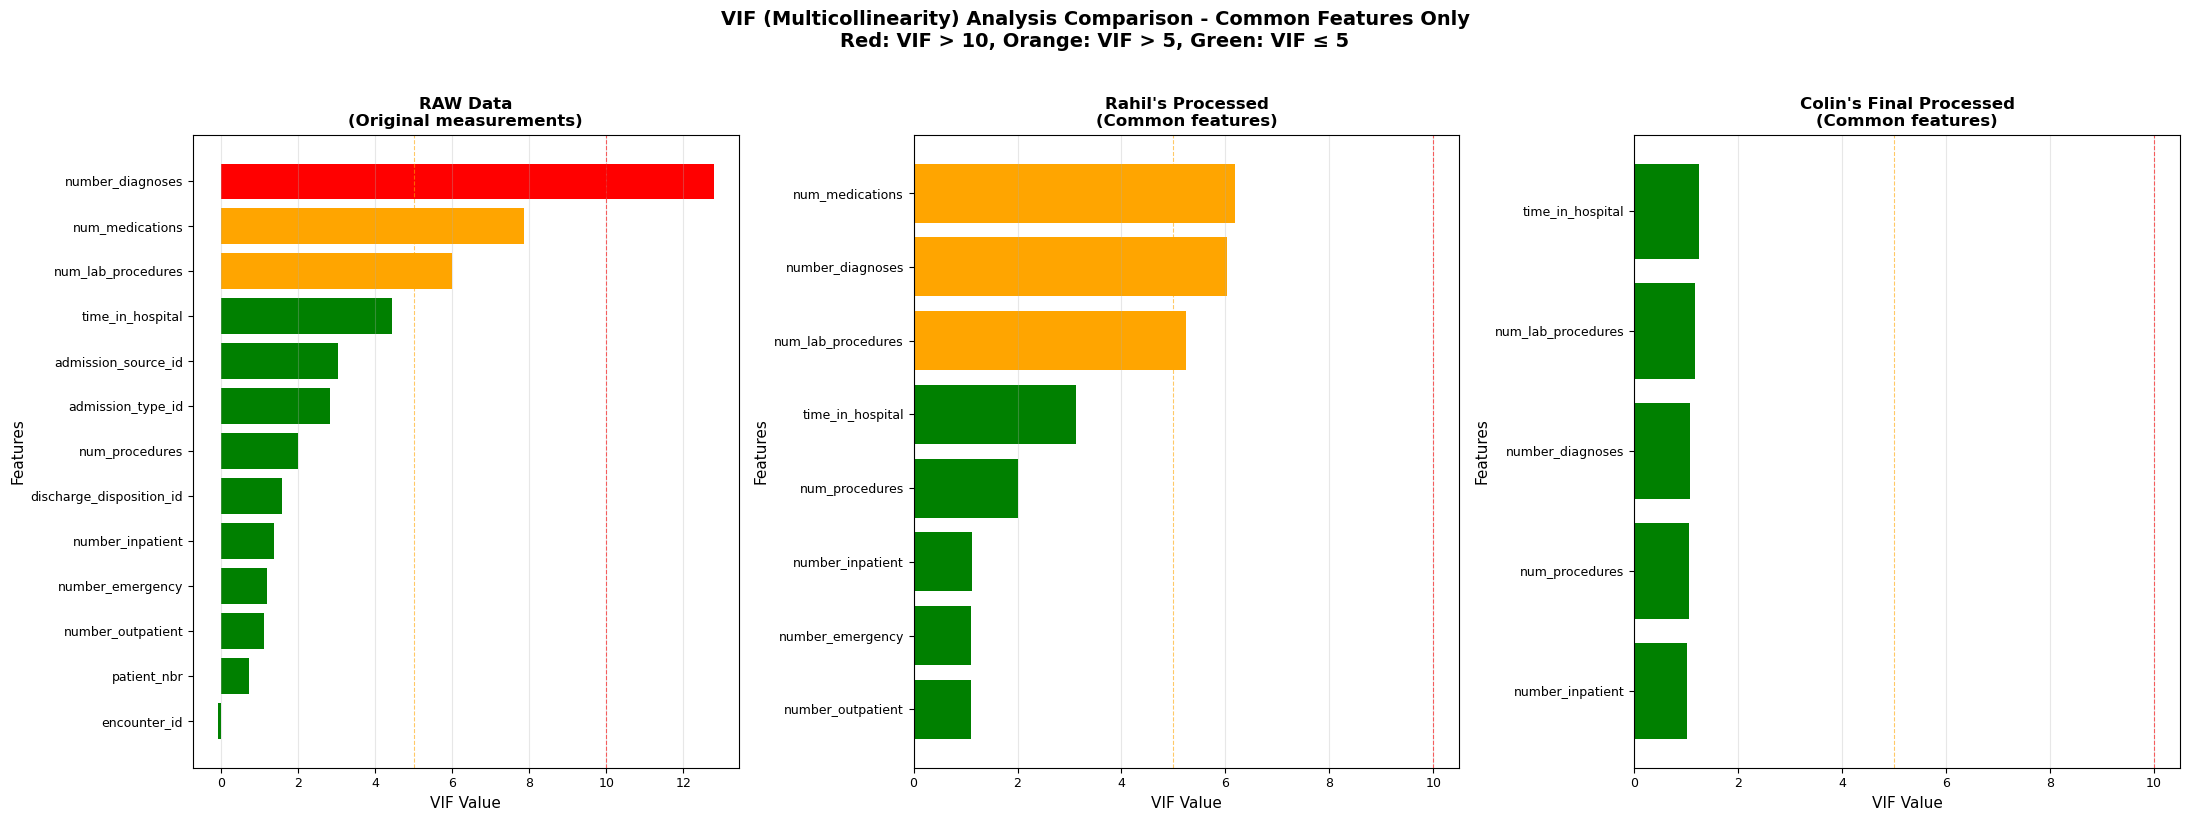

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Use only features that exist in RAW data for apples-to-apples comparison
common_features = raw_numerical_cols.copy()
print(f"Comparing {len(common_features)} features that exist in raw data: {common_features}")

# Prepare RAW data for VIF calculation
X_vif_raw = df[common_features].copy()
X_vif_raw = X_vif_raw.loc[:, X_vif_raw.std() > 0]
if len(X_vif_raw) > 10000:
    X_vif_raw = X_vif_raw.sample(n=10000, random_state=34)
X_vif_raw = X_vif_raw.dropna()

# Calculate VIF for RAW data
print("Calculating VIF for raw data...")
vif_raw_data = []
for i, col in enumerate(X_vif_raw.columns):
    try:
        vif = variance_inflation_factor(X_vif_raw.values, i)
        vif_raw_data.append({'Feature': col, 'VIF': vif})
    except:
        vif_raw_data.append({'Feature': col, 'VIF': np.nan})

vif_raw_df = pd.DataFrame(vif_raw_data).sort_values('VIF', ascending=False)

# Prepare RAHIL's TRAINING data for VIF calculation (only common features)
rahil_common = [col for col in common_features if col in df_train.columns]
X_vif_rahil = df_train[rahil_common].copy()
X_vif_rahil = X_vif_rahil.loc[:, X_vif_rahil.std() > 0]
if len(X_vif_rahil) > 10000:
    X_vif_rahil = X_vif_rahil.sample(n=10000, random_state=34)
X_vif_rahil = X_vif_rahil.dropna()

# Calculate VIF for RAHIL's TRAINING data
print(f"Calculating VIF for Rahil's training data ({len(rahil_common)} common features)...")
vif_rahil_data = []
for i, col in enumerate(X_vif_rahil.columns):
    try:
        vif = variance_inflation_factor(X_vif_rahil.values, i)
        vif_rahil_data.append({'Feature': col, 'VIF': vif})
    except:
        vif_rahil_data.append({'Feature': col, 'VIF': np.nan})
vif_rahil_df = pd.DataFrame(vif_rahil_data).sort_values('VIF', ascending=False)

# Prepare COLIN's final TRAINING data for VIF calculation (only common features)
colin_common = [col for col in common_features if col in X_train_final_selected.columns]
X_vif_colin = X_train_final_selected[colin_common].copy()
X_vif_colin = X_vif_colin.loc[:, X_vif_colin.std() > 0]
if len(X_vif_colin) > 10000:
    X_vif_colin = X_vif_colin.sample(n=10000, random_state=34)
X_vif_colin = X_vif_colin.dropna()

# Calculate VIF for COLIN's TRAINING data
print(f"Calculating VIF for Colin's final training data ({len(colin_common)} common features)...")
vif_colin_data = []
for i, col in enumerate(X_vif_colin.columns):
    try:
        vif = variance_inflation_factor(X_vif_colin.values, i)
        vif_colin_data.append({'Feature': col, 'VIF': vif})
    except:
        vif_colin_data.append({'Feature': col, 'VIF': np.nan})
vif_colin_df = pd.DataFrame(vif_colin_data).sort_values('VIF', ascending=False)

# Comparison statistics
print("="*80)
print("VIF COMPARISON: RAW vs RAHIL vs COLIN")
print("="*80)

print(f"\n1. Raw Data:")
print(f"   Total features: {len(vif_raw_df)}")
print(f"   Mean VIF: {vif_raw_df['VIF'].mean():.2f}")
print(f"   Max VIF: {vif_raw_df['VIF'].max():.2f}")
print(f"   High multicollinearity (VIF > 10): {(vif_raw_df['VIF'] > 10).sum()}")
print(f"   Moderate multicollinearity (VIF > 5): {(vif_raw_df['VIF'] > 5).sum()}")

print(f"\n2. Rahil's Processed Data:")
print(f"   Total features: {len(vif_rahil_df)}")
print(f"   Mean VIF: {vif_rahil_df['VIF'].mean():.2f}")
print(f"   Max VIF: {vif_rahil_df['VIF'].max():.2f}")
print(f"   High multicollinearity (VIF > 10): {(vif_rahil_df['VIF'] > 10).sum()}")
print(f"   Moderate multicollinearity (VIF > 5): {(vif_rahil_df['VIF'] > 5).sum()}")

print(f"\n3. Colin's Final Processed Data:")
print(f"   Total features: {len(vif_colin_df)}")
print(f"   Mean VIF: {vif_colin_df['VIF'].mean():.2f}")
print(f"   Max VIF: {vif_colin_df['VIF'].max():.2f}")
print(f"   High multicollinearity (VIF > 10): {(vif_colin_df['VIF'] > 10).sum()}")
print(f"   Moderate multicollinearity (VIF > 5): {(vif_colin_df['VIF'] > 5).sum()}")
print("="*80)

print("\n NOTE: Comparing only the features present in RAW data for apples-to-apples comparison.")
print("This excludes one-hot encoded categorical variables that cause infinite VIF.")
print("="*80)

# Create three-panel comparison
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 8))

# Plot RAW data VIF (all features since we filtered to common ones)
colors_raw = ['red' if x > 10 else 'orange' if x > 5 else 'green' 
              for x in vif_raw_df['VIF'].fillna(0)]
ax1.barh(vif_raw_df['Feature'], vif_raw_df['VIF'], color=colors_raw)
ax1.set_xlabel('VIF Value', fontsize=11)
ax1.set_ylabel('Features', fontsize=11)
ax1.set_title('RAW Data\n(Original measurements)', fontsize=12, fontweight='bold')
ax1.axvline(x=5, color='orange', linestyle='--', linewidth=0.8, alpha=0.6)
ax1.axvline(x=10, color='red', linestyle='--', linewidth=0.8, alpha=0.6)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)
ax1.tick_params(axis='both', labelsize=9)

# Plot RAHIL's processed data VIF (all common features)
colors_rahil = ['red' if x > 10 else 'orange' if x > 5 else 'green' 
                for x in vif_rahil_df['VIF'].fillna(0)]
ax2.barh(vif_rahil_df['Feature'], vif_rahil_df['VIF'], color=colors_rahil)
ax2.set_xlabel('VIF Value', fontsize=11)
ax2.set_ylabel('Features', fontsize=11)
ax2.set_title("Rahil's Processed\n(Common features)", fontsize=12, fontweight='bold')
ax2.axvline(x=5, color='orange', linestyle='--', linewidth=0.8, alpha=0.6)
ax2.axvline(x=10, color='red', linestyle='--', linewidth=0.8, alpha=0.6)
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)
ax2.tick_params(axis='both', labelsize=9)

# Plot COLIN's dev processed data VIF (all common features)
colors_colin = ['red' if x > 10 else 'orange' if x > 5 else 'green' 
                for x in vif_colin_df['VIF'].fillna(0)]
ax3.barh(vif_colin_df['Feature'], vif_colin_df['VIF'], color=colors_colin)
ax3.set_xlabel('VIF Value', fontsize=11)
ax3.set_ylabel('Features', fontsize=11)
ax3.set_title("Colin's Final Processed\n(Common features)", fontsize=12, fontweight='bold')
ax3.axvline(x=5, color='orange', linestyle='--', linewidth=0.8, alpha=0.6)
ax3.axvline(x=10, color='red', linestyle='--', linewidth=0.8, alpha=0.6)
ax3.invert_yaxis()
ax3.grid(axis='x', alpha=0.3)
ax3.tick_params(axis='both', labelsize=9)

fig.suptitle('VIF (Multicollinearity) Analysis Comparison - Common Features Only\nRed: VIF > 10, Orange: VIF > 5, Green: VIF ≤ 5', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

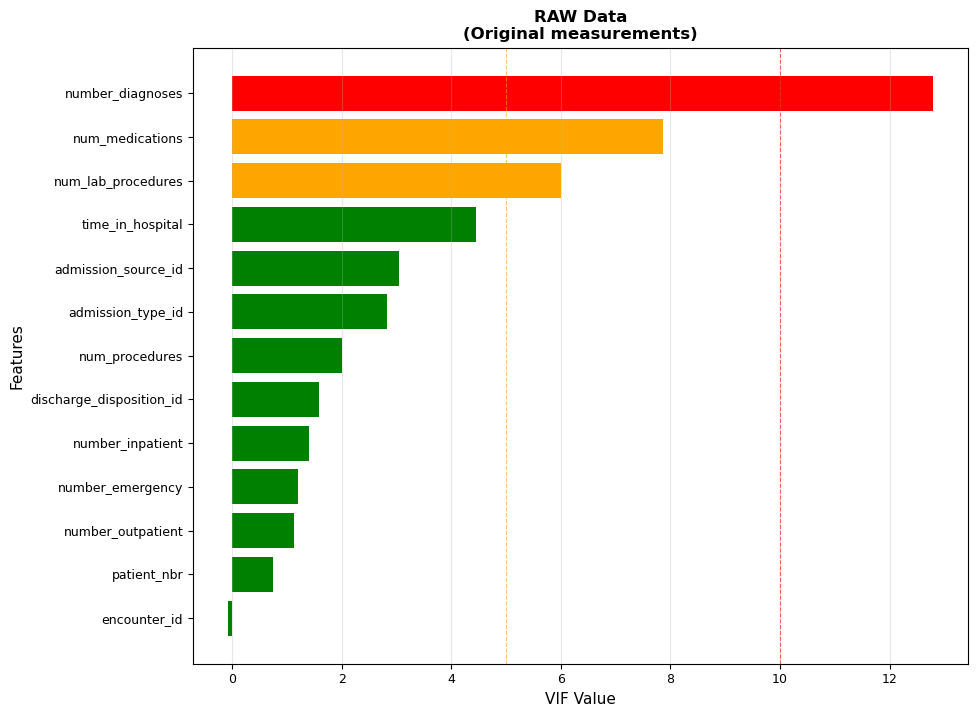

In [13]:
# Prepare RAW data for VIF calculation
X_vif_raw = df[common_features].copy()
X_vif_raw = X_vif_raw.loc[:, X_vif_raw.std() > 0]
if len(X_vif_raw) > 10000:
    X_vif_raw = X_vif_raw.sample(n=10000, random_state=34)
X_vif_raw = X_vif_raw.dropna()

# Calculate VIF for RAW data
vif_raw_data = []
for i, col in enumerate(X_vif_raw.columns):
    try:
        vif = variance_inflation_factor(X_vif_raw.values, i)
        vif_raw_data.append({'Feature': col, 'VIF': vif})
    except:
        vif_raw_data.append({'Feature': col, 'VIF': np.nan})

vif_raw_df = pd.DataFrame(vif_raw_data).sort_values('VIF', ascending=False)

# Plot RAW data VIF (all features since we filtered to common ones)

fig, ax1 = plt.subplots(1, 1, figsize=(10, 8))
colors_raw = ['red' if x > 10 else 'orange' if x > 5 else 'green' 
              for x in vif_raw_df['VIF'].fillna(0)]
ax1.barh(vif_raw_df['Feature'], vif_raw_df['VIF'], color=colors_raw)
ax1.set_xlabel('VIF Value', fontsize=11)
ax1.set_ylabel('Features', fontsize=11)
ax1.set_title('RAW Data\n(Original measurements)', fontsize=12, fontweight='bold')
ax1.axvline(x=5, color='orange', linestyle='--', linewidth=0.8, alpha=0.6)
ax1.axvline(x=10, color='red', linestyle='--', linewidth=0.8, alpha=0.6)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)
ax1.tick_params(axis='both', labelsize=9)

plt.show()

### 2.1.3 Kurtosis Analysis

KURTOSIS COMPARISON: RAW vs RAHIL vs COLIN

1. Raw Data:
   Total features: 13
   Mean kurtosis: 105.718
   Heavy-tailed (kurtosis > 3): 5
   Light-tailed (kurtosis < -1): 0

2. Rahil's Processed Data:
   Total features: 42
   Mean kurtosis: 4758.364
   Heavy-tailed (kurtosis > 3): 26
   Light-tailed (kurtosis < -1): 4

3. Colin's Final Processed Data:
   Total features: 25
   Mean kurtosis: 5.595
   Heavy-tailed (kurtosis > 3): 8
   Light-tailed (kurtosis < -1): 6


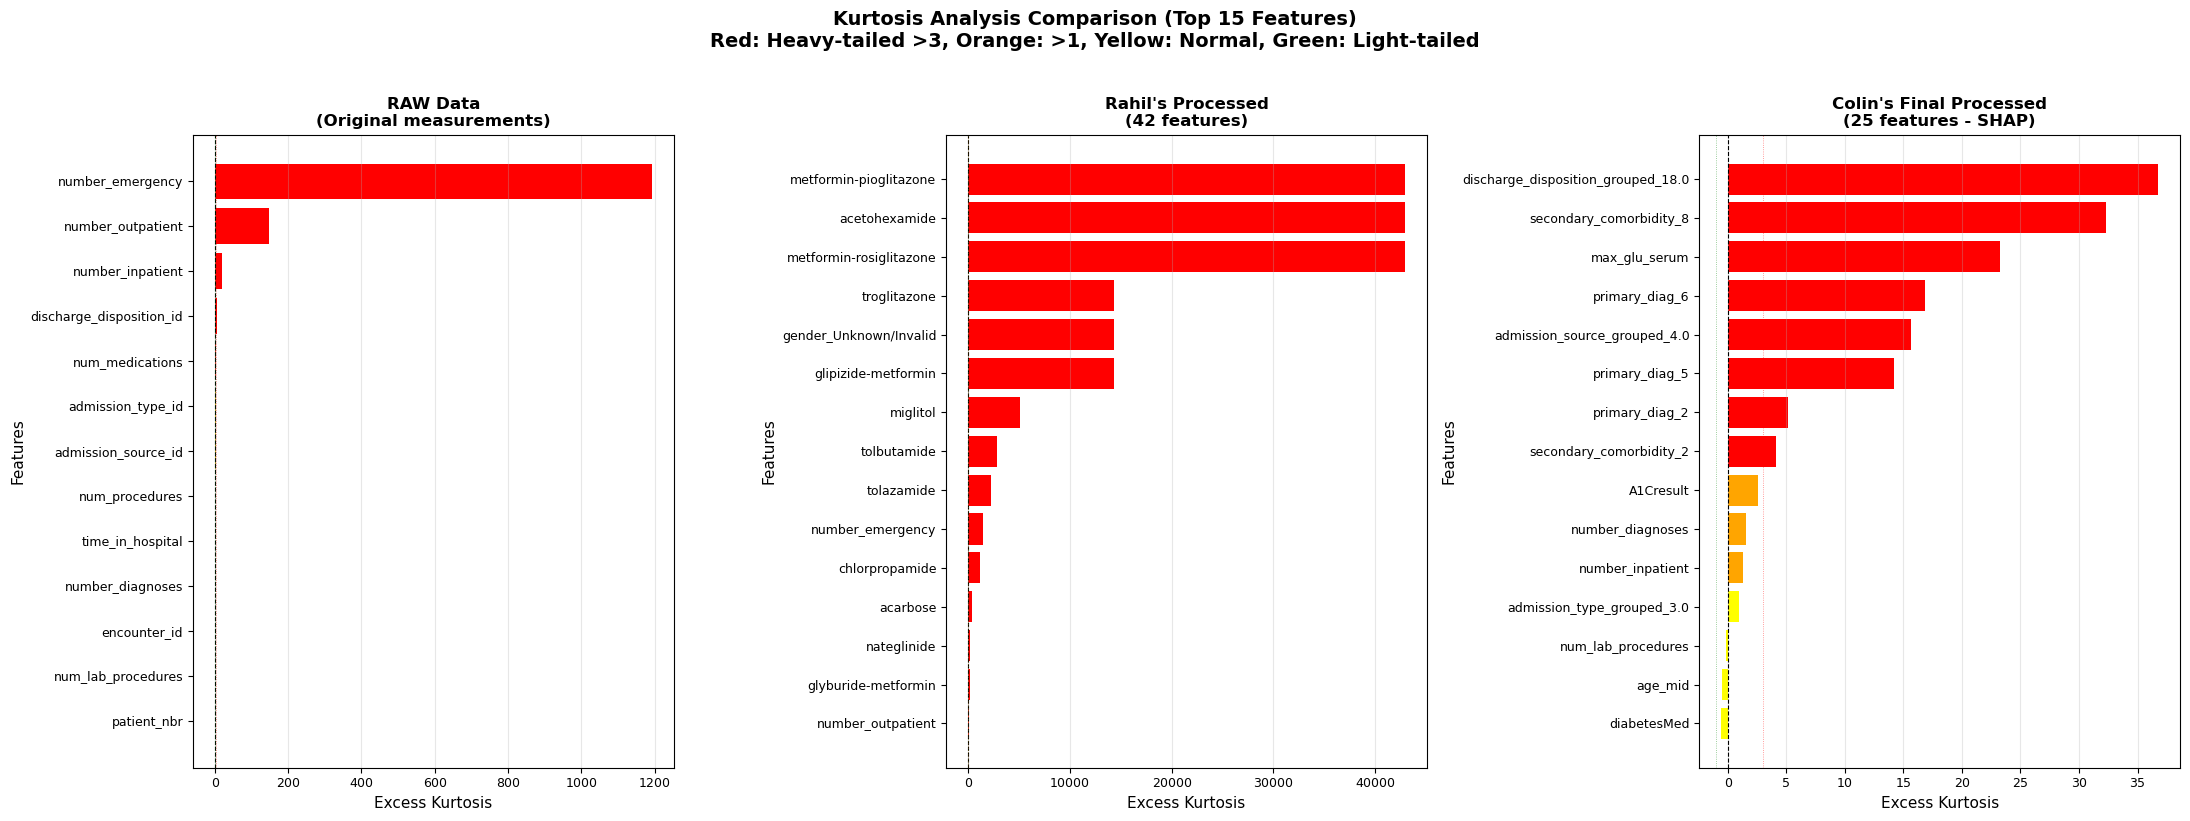

In [14]:
from scipy.stats import kurtosis

# Calculate kurtosis for RAW data (Fisher's definition: excess kurtosis)
kurtosis_raw = []
for col in raw_numerical_cols:
    kurt_value = kurtosis(df[col].dropna(), fisher=True)
    kurtosis_raw.append({'Feature': col, 'Kurtosis': kurt_value})

kurtosis_raw_df = pd.DataFrame(kurtosis_raw).sort_values('Kurtosis', ascending=False)

# Calculate kurtosis for RAHIL's TRAINING data
kurtosis_rahil = []
for col in rahil_numerical_cols:
    kurt_value = kurtosis(df_train[col].dropna(), fisher=True)
    kurtosis_rahil.append({'Feature': col, 'Kurtosis': kurt_value})
kurtosis_rahil_df = pd.DataFrame(kurtosis_rahil).sort_values('Kurtosis', ascending=False)

# Calculate kurtosis for COLIN's final TRAINING data
kurtosis_colin = []
for col in colin_numerical_cols:
    kurt_value = kurtosis(X_train_final_selected[col].dropna(), fisher=True)
    kurtosis_colin.append({'Feature': col, 'Kurtosis': kurt_value})
kurtosis_colin_df = pd.DataFrame(kurtosis_colin).sort_values('Kurtosis', ascending=False)

# Comparison statistics
print("="*80)
print("KURTOSIS COMPARISON: RAW vs RAHIL vs COLIN")
print("="*80)
print(f"\n1. Raw Data:")
print(f"   Total features: {len(kurtosis_raw_df)}")
print(f"   Mean kurtosis: {kurtosis_raw_df['Kurtosis'].mean():.3f}")
print(f"   Heavy-tailed (kurtosis > 3): {(kurtosis_raw_df['Kurtosis'] > 3).sum()}")
print(f"   Light-tailed (kurtosis < -1): {(kurtosis_raw_df['Kurtosis'] < -1).sum()}")

print(f"\n2. Rahil's Processed Data:")
print(f"   Total features: {len(kurtosis_rahil_df)}")
print(f"   Mean kurtosis: {kurtosis_rahil_df['Kurtosis'].mean():.3f}")
print(f"   Heavy-tailed (kurtosis > 3): {(kurtosis_rahil_df['Kurtosis'] > 3).sum()}")
print(f"   Light-tailed (kurtosis < -1): {(kurtosis_rahil_df['Kurtosis'] < -1).sum()}")

print(f"\n3. Colin's Final Processed Data:")
print(f"   Total features: {len(kurtosis_colin_df)}")
print(f"   Mean kurtosis: {kurtosis_colin_df['Kurtosis'].mean():.3f}")
print(f"   Heavy-tailed (kurtosis > 3): {(kurtosis_colin_df['Kurtosis'] > 3).sum()}")
print(f"   Light-tailed (kurtosis < -1): {(kurtosis_colin_df['Kurtosis'] < -1).sum()}")
print("="*80)

# Create three-panel comparison
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 8))

# Plot RAW data kurtosis (top 15)
top_kurt_raw = kurtosis_raw_df.head(15)
colors_raw = ['red' if x > 3 else 'orange' if x > 1 else 'yellow' if x > -1 else 'green' 
              for x in top_kurt_raw['Kurtosis']]
ax1.barh(top_kurt_raw['Feature'], top_kurt_raw['Kurtosis'], color=colors_raw)
ax1.set_xlabel('Excess Kurtosis', fontsize=11)
ax1.set_ylabel('Features', fontsize=11)
ax1.set_title('RAW Data\n(Original measurements)', fontsize=12, fontweight='bold')
ax1.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax1.axvline(x=3, color='red', linestyle=':', linewidth=0.6, alpha=0.5)
ax1.axvline(x=-1, color='green', linestyle=':', linewidth=0.6, alpha=0.5)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)
ax1.tick_params(axis='both', labelsize=9)

# Plot RAHIL's processed data kurtosis (top 15)
top_kurt_rahil = kurtosis_rahil_df.head(15)
colors_rahil = ['red' if x > 3 else 'orange' if x > 1 else 'yellow' if x > -1 else 'green' 
                for x in top_kurt_rahil['Kurtosis']]
ax2.barh(top_kurt_rahil['Feature'], top_kurt_rahil['Kurtosis'], color=colors_rahil)
ax2.set_xlabel('Excess Kurtosis', fontsize=11)
ax2.set_ylabel('Features', fontsize=11)
ax2.set_title("Rahil's Processed\n(42 features)", fontsize=12, fontweight='bold')
ax2.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax2.axvline(x=3, color='red', linestyle=':', linewidth=0.6, alpha=0.5)
ax2.axvline(x=-1, color='green', linestyle=':', linewidth=0.6, alpha=0.5)
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)
ax2.tick_params(axis='both', labelsize=9)

# Plot COLIN's final processed data kurtosis (top 15)
top_kurt_colin = kurtosis_colin_df.head(15)
colors_colin = ['red' if x > 3 else 'orange' if x > 1 else 'yellow' if x > -1 else 'green' 
                for x in top_kurt_colin['Kurtosis']]
ax3.barh(top_kurt_colin['Feature'], top_kurt_colin['Kurtosis'], color=colors_colin)
ax3.set_xlabel('Excess Kurtosis', fontsize=11)
ax3.set_ylabel('Features', fontsize=11)
ax3.set_title("Colin's Final Processed\n(25 features - SHAP)", fontsize=12, fontweight='bold')
ax3.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax3.axvline(x=3, color='red', linestyle=':', linewidth=0.6, alpha=0.5)
ax3.axvline(x=-1, color='green', linestyle=':', linewidth=0.6, alpha=0.5)
ax3.invert_yaxis()
ax3.grid(axis='x', alpha=0.3)
ax3.tick_params(axis='both', labelsize=9)

fig.suptitle('Kurtosis Analysis Comparison (Top 15 Features)\nRed: Heavy-tailed >3, Orange: >1, Yellow: Normal, Green: Light-tailed', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

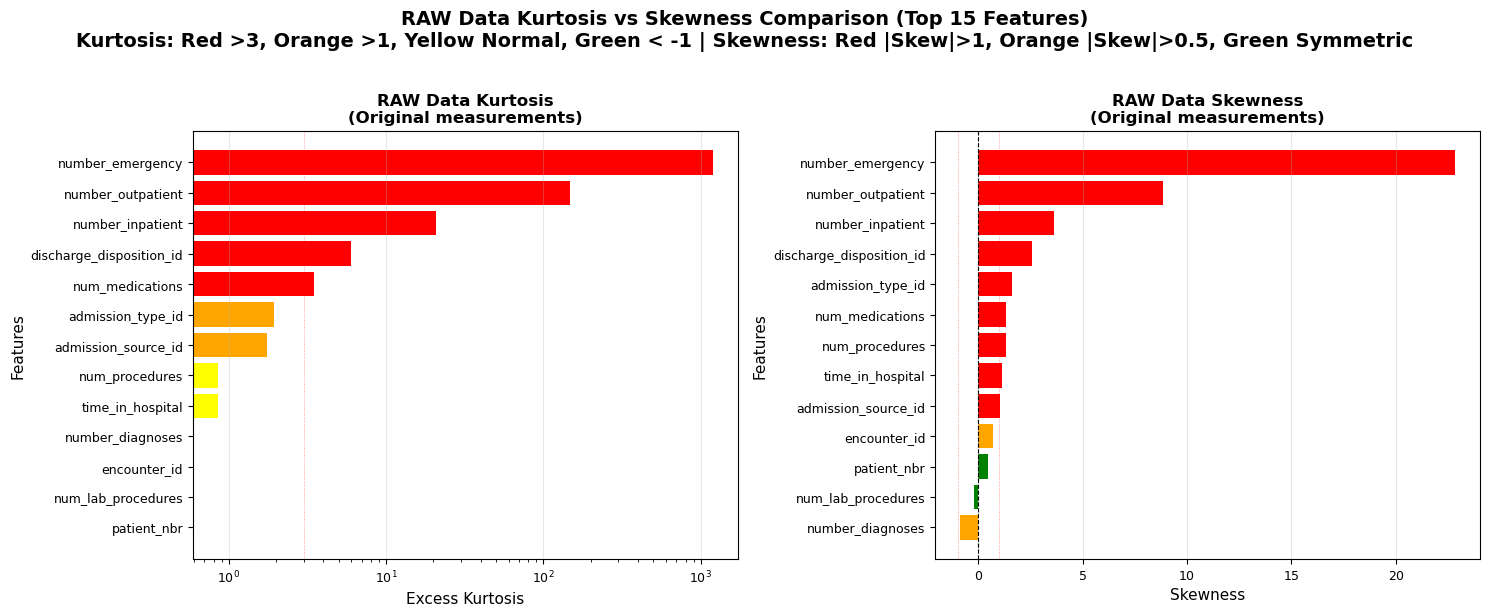

In [15]:
# Plot Just Raw Data Kurtosis and Skewness Side by Side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
# Plot RAW data kurtosis (top 15) - use log scale for better visibility 
top_kurt_raw = kurtosis_raw_df.head(15)
colors_raw_kurt = ['red' if x > 3 else 'orange' if x > 1 else 'yellow' if x > -1 else 'green' 
              for x in top_kurt_raw['Kurtosis']]
ax1.barh(top_kurt_raw['Feature'], top_kurt_raw['Kurtosis'], color=colors_raw_kurt)
ax1.set_xlabel('Excess Kurtosis', fontsize=11)
ax1.set_ylabel('Features', fontsize=11)
ax1.set_xscale('log')
ax1.set_title('RAW Data Kurtosis\n(Original measurements)', fontsize=12, fontweight='bold')
ax1.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax1.axvline(x=3, color='red', linestyle=':', linewidth=0.6, alpha=0.5)
ax1.axvline(x=-1, color='green', linestyle=':', linewidth=0.6, alpha=0.5)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)
ax1.tick_params(axis='both', labelsize=9)
# Plot RAW data skewness (top 15)
top_skew_raw = skewness_raw_df.head(15)
colors_raw_skew = ['red' if abs(x) > 1 else 'orange' if abs(x) > 0.5 else 'green' 
              for x in top_skew_raw['Skewness']]
ax2.barh(top_skew_raw['Feature'], top_skew_raw['Skewness'], color=colors_raw_skew)
ax2.set_xlabel('Skewness', fontsize=11)
ax2.set_ylabel('Features', fontsize=11)
ax2.set_title('RAW Data Skewness\n(Original measurements)', fontsize=12, fontweight='bold')
ax2.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax2.axvline(x=1, color='red', linestyle=':', linewidth=0.6, alpha=0.5)
ax2.axvline(x=-1, color='red', linestyle=':', linewidth=0.6, alpha=0.5)
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)
ax2.tick_params(axis='both', labelsize=9)   
fig.suptitle('RAW Data Kurtosis vs Skewness Comparison (Top 15 Features)\nKurtosis: Red >3, Orange >1, Yellow Normal, Green < -1 | Skewness: Red |Skew|>1, Orange |Skew|>0.5, Green Symmetric', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. Transformer Model 

### 3.0 Custom Loss Functions and Metrics

In [16]:
class F1Score(keras.metrics.Metric):
    """
    Custom F1 Score metric for binary classification.
    
    F1 = 2 * (precision * recall) / (precision + recall)
    """
    def __init__(self, name='f1_score', threshold=0.5, **kwargs):
        super().__init__(name=name, **kwargs)
        self.threshold = threshold
        self.true_positives = self.add_weight(name='tp', initializer='zeros')
        self.false_positives = self.add_weight(name='fp', initializer='zeros')
        self.false_negatives = self.add_weight(name='fn', initializer='zeros')
    def update_state(self, y_true, y_pred, sample_weight=None):
        # Convert predictions to binary using threshold
        y_pred = tf.cast(y_pred >= self.threshold, tf.float32)
        y_true = tf.cast(y_true, tf.float32)
        
        # Calculate true positives, false positives, false negatives
        tp = tf.reduce_sum(y_true * y_pred)
        fp = tf.reduce_sum((1 - y_true) * y_pred)
        fn = tf.reduce_sum(y_true * (1 - y_pred))
        
        self.true_positives.assign_add(tp)
        self.false_positives.assign_add(fp)
        self.false_negatives.assign_add(fn)
    
    def result(self):
        precision = self.true_positives / (self.true_positives + self.false_positives + keras.backend.epsilon())
        recall = self.true_positives / (self.true_positives + self.false_negatives + keras.backend.epsilon())
        f1 = 2 * (precision * recall) / (precision + recall + keras.backend.epsilon())
        return f1
    
    def reset_state(self):
        self.true_positives.assign(0)
        self.false_positives.assign(0)
        self.false_negatives.assign(0)
    
    def get_config(self):
        config = super().get_config()
        config.update({"threshold": self.threshold})
        return config


def calculate_class_weights(y_train):
    """
    Calculate class weights for imbalanced datasets.
    
    Args:
        y_train: Training labels
        
    Returns:
        Dictionary of class weights
    """
    from sklearn.utils.class_weight import compute_class_weight
    
    classes = np.unique(y_train)
    weights = compute_class_weight('balanced', classes=classes, y=y_train.ravel())
    class_weights = dict(zip(classes, weights))
    
    print(f"Calculated class weights: {class_weights}")
    return class_weights

In [17]:
def build_transformer_model(
    input_shape: int,
    num_classes: int = 2,
    embedding_dim: int = 64,
    num_heads: int = 4,
    key_dim: int = 16,
    ffn_dim: int = 128,
    dense_dim: int = 32,
):
    """
    Build a simplified transformer model for readmission prediction.
    
    Reduced complexity due to:
    - SHAP feature selection (25 features instead of 48)
    - SMOTE-balanced training data
    - Reduced multicollinearity and improved feature quality

    Args:
        input_shape: Number of input features
        num_classes: Number of output classes
        embedding_dim: Dimension of embedding layer (reduced from 192 to 64)
        num_heads: Number of attention heads (reduced from 8 to 4)
        key_dim: Dimension of key in attention (reduced from 24 to 16)
        ffn_dim: Dimension of feed-forward network (reduced from 2048 to 128)
        dense_dim: Dimension of final dense layer (reduced from 64 to 32)

    Returns:
        Compiled Keras model
    """

    inputs = keras.Input(shape=(input_shape,))

    # Embedding layer
    x = keras.layers.Dense(
        embedding_dim, activation="relu", kernel_regularizer=keras.regularizers.l2(0.01)
    )(inputs)
    x = keras.layers.Reshape((1, embedding_dim))(x)

    # Dropout layer
    x = keras.layers.Dropout(0.2)(x)

    # Transformer block
    attention_output = keras.layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=key_dim
    )(x, x)
    x = keras.layers.Add()([x, attention_output])
    x = keras.layers.LayerNormalization()(x)

    # Feed-forward network
    ffn_output = keras.layers.Dense(
        ffn_dim, activation="relu", kernel_regularizer=keras.regularizers.l2(0.01)
    )(x)
    ffn_output = keras.layers.Dense(
        embedding_dim, kernel_regularizer=keras.regularizers.l2(0.01)
    )(ffn_output)
    x = keras.layers.Add()([x, ffn_output])
    x = keras.layers.LayerNormalization()(x)

    # Pooling layer
    x = keras.layers.GlobalAveragePooling1D()(x)

    # Dropout layer
    x = keras.layers.Dropout(0.2)(x)

    # Output layers
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(
        dense_dim, activation="relu", kernel_regularizer=keras.regularizers.l2(0.01)
    )(x)
    outputs = keras.layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

In [18]:
def train_transformer_model(
    X_train: pd.DataFrame,
    Y_train: pd.Series,
    X_val: pd.DataFrame,
    Y_val: pd.Series,
    epochs: int = 10,
    batch_size: int = 64,
    verbose: int = 1,
    use_class_weights: bool = True,
):
    """
    Train a transformer model for readmission prediction.

    Args:
        X_train: Training features
        Y_train: Training target
        X_val: Validation features
        Y_val: Validation target
        epochs: Number of training epochs
        batch_size: Batch size for training
        verbose: Verbosity level (0, 1, or 2)
        use_class_weights: Whether to use class weights (default: True)

    Returns:
        Tuple of (trained model, training history)
    """

    early_stopping_callback = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        min_delta=0.001,
        patience=5,
        verbose=1,
        mode="min",
        restore_best_weights=True,
    )

    input_shape = X_train.shape[1]
    num_classes = len(np.unique(Y_train))

    model = build_transformer_model(input_shape, num_classes)

    # Use binary crossentropy loss
    print("Using Binary Crossentropy Loss with Class Weights")

    # Calculate class weights if requested
    class_weights = None
    if use_class_weights:
        class_weights = calculate_class_weights(Y_train)

    # Compile model with F1 Score metric
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy", F1Score(threshold=0.5)],
    )

    # Fit model
    history = model.fit(
        X_train,
        Y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val, Y_val),
        class_weight=class_weights,
        callbacks=[early_stopping_callback],
        verbose=verbose,
    )

    return model, history

In [19]:
def plot_training_history(history, title_prefix="Model"):
    """
    Plot training and validation metrics over epochs.

    Args:
        history: Keras History object from model training
        title_prefix: Prefix for plot titles
    """
    # Check if F1 score is in history
    has_f1 = 'f1_score' in history.history
    
    if has_f1:
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
    else:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Plot accuracy
    ax1.plot(history.history["accuracy"], label="Train Accuracy")
    ax1.plot(history.history["val_accuracy"], label="Val Accuracy")
    ax1.set_title(f"{title_prefix} Accuracy")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Plot loss
    ax2.plot(history.history["loss"], label="Train Loss")
    ax2.plot(history.history["val_loss"], label="Val Loss")
    ax2.set_title(f"{title_prefix} Loss")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.legend()
    ax2.grid(alpha=0.3)

    # Plot F1 score if available
    if has_f1:
        ax3.plot(history.history["f1_score"], label="Train F1 Score")
        ax3.plot(history.history["val_f1_score"], label="Val F1 Score")
        ax3.set_title(f"{title_prefix} F1 Score")
        ax3.set_xlabel("Epoch")
        ax3.set_ylabel("F1 Score")
        ax3.legend()
        ax3.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

**Model Configuration:**
- Loss Function: Binary Crossentropy
- Class Weights: Enabled (automatically calculated from data)
- SMOTE: Applied to training data (balanced 1:1 ratio)
- Metrics: Accuracy + F1 Score
- Simplified Architecture: Reduced complexity due to SHAP feature selection and improved data quality

In [20]:
# Train the transformer model on Rahil's data splits
# Using binary crossentropy with class weights
model_rahil, history_rahil = train_transformer_model(
    X_train=df_train[df_train.columns.difference(["readmitted"])],
    Y_train=df_train["readmitted"],
    X_val=df_val[df_val.columns.difference(["readmitted"])],
    Y_val=df_val["readmitted"],
    epochs=10,
    batch_size=64,
    verbose=1,
    use_class_weights=True,
)

Using Binary Crossentropy Loss with Class Weights
Calculated class weights: {np.int64(0): np.float64(0.5483986401860798), np.int64(1): np.float64(5.6654343807763405)}
Epoch 1/10


E0000 00:00:1765225788.134345   29464 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1765225788.137879   29464 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


671/671 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5059 - f1_score: 0.1603 - loss: 1.2614 - val_accuracy: 0.8519 - val_f1_score: 0.1010 - val_loss: 0.6921
Epoch 2/10
671/671 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5059 - f1_score: 0.1603 - loss: 1.2614 - val_accuracy: 0.8519 - val_f1_score: 0.1010 - val_loss: 0.6921
Epoch 2/10
671/671 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5200 - f1_score: 0.1611 - loss: 0.7221 - val_accuracy: 0.4516 - val_f1_score: 0.1715 - val_loss: 0.7044
Epoch 3/10
671/671 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5200 - f1_score: 0.1611 - loss: 0.7221 - val_accuracy: 0.4516 - val_f1_score: 0.1715 - val_loss: 0.7044
Epoch 3/10
671/671 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4683 - f1_score: 0.1665 - loss: 0.6989 - val_accuracy: 0.3277 - val_f1_score: 0.1760 - val_loss: 0.7060
Epoch 4/10
671/671 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4683 - f1_score: 0.1665 - loss: 0.6989 - val_accuracy: 0.3277 - val_f1_score: 0.1760 - val_loss

### 3.1 Train on Rahil's Data Splits

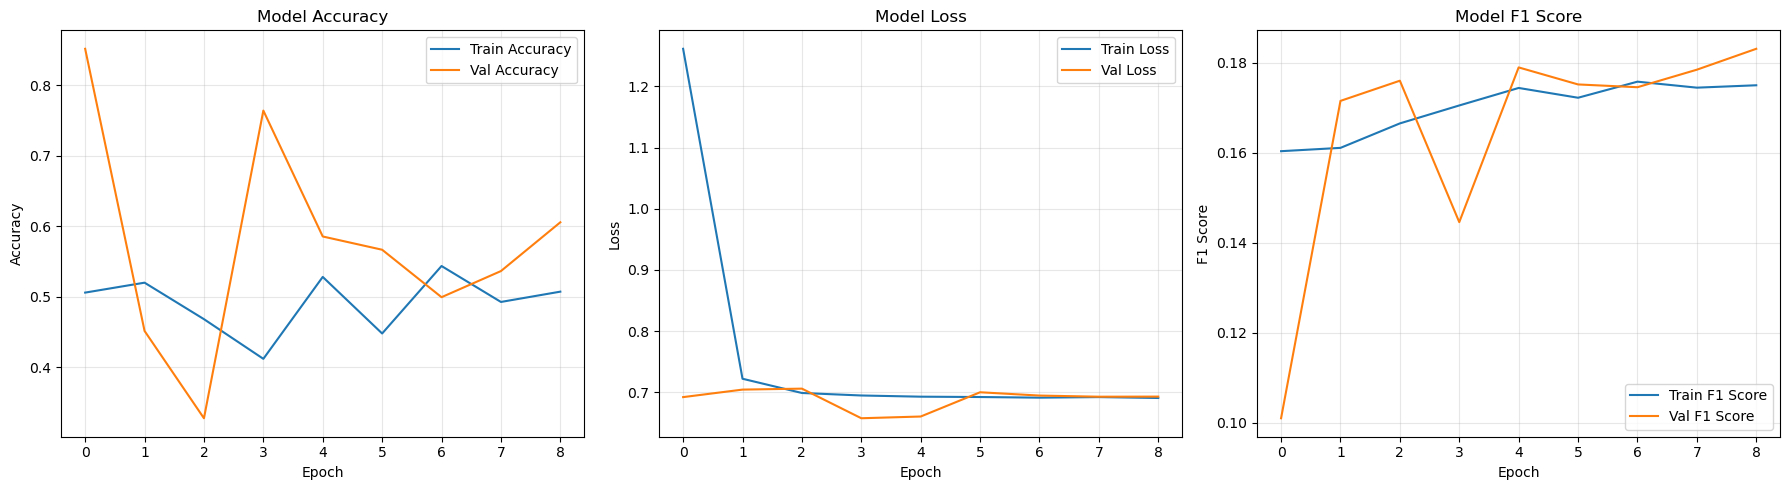

In [21]:
# Plot training history for Rahil's data
plot_training_history(history_rahil)

In [22]:
# Evaluate on Rahil's test set
eval_results_rahil = model_rahil.evaluate(
    df_test[df_test.columns.difference(["readmitted"])],
    df_test["readmitted"],
    verbose=1,
)
test_loss_rahil, test_accuracy_rahil, test_f1_rahil = eval_results_rahil
print(
    f"\nRahil's Data - Test Loss: {test_loss_rahil:.4f}, Test Accuracy: {test_accuracy_rahil:.4f}, Test F1: {test_f1_rahil:.4f}"
)

447/447 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7567 - f1_score: 0.1382 - loss: 0.6587

Rahil's Data - Test Loss: 0.6587, Test Accuracy: 0.7567, Test F1: 0.1382
447/447 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7567 - f1_score: 0.1382 - loss: 0.6587

Rahil's Data - Test Loss: 0.6587, Test Accuracy: 0.7567, Test F1: 0.1382


### 3.2 Train on Colin's Final Data Splits (SHAP-selected features)

In [23]:
# Note: We're already using the transformed data loaded at the beginning
# X_train_final_selected, X_val_final_selected, X_test_final_selected
# are already the transformed versions from:
# - X_train_final_selected_transformed.csv
# - X_val_final_selected_transformed.csv  
# - X_test_final_selected_transformed.csv

print("=" * 70)
print("TRANSFORMED DATA CONFIRMATION")
print("=" * 70)
print("Using transformed datasets loaded from:")
print("  - ../data/X_train_final_selected_transformed.csv")
print("  - ../data/X_val_final_selected_transformed.csv")
print("  - ../data/X_test_final_selected_transformed.csv")
print("\nThese datasets have:")
print("  ✓ SHAP-refined features (25 features)")
print("  ✓ Yeo-Johnson power transformation applied")
print("  ✓ Reduced skewness and kurtosis")
print("  ✓ Standardized continuous features")
print("=" * 70)

TRANSFORMED DATA CONFIRMATION
Using transformed datasets loaded from:
  - ../data/X_train_final_selected_transformed.csv
  - ../data/X_val_final_selected_transformed.csv
  - ../data/X_test_final_selected_transformed.csv

These datasets have:
  ✓ SHAP-refined features (25 features)
  ✓ Yeo-Johnson power transformation applied
  ✓ Reduced skewness and kurtosis
  ✓ Standardized continuous features


In [24]:
# Train the transformer model on Colin's final TRANSFORMED data splits
# Data is already transformed (loaded from X_train_final_selected_transformed.csv)
# Now applying SMOTE to the already-transformed training data
model_colin_dev, history_colin_dev = train_transformer_model(
    X_train=X_train_final_selected,  # Already transformed data with SMOTE applied earlier
    Y_train=Y_train_final.values.ravel(),
    X_val=X_val_final_selected,  # Already transformed validation data
    Y_val=Y_val_final.values.ravel(),
    epochs=10,
    batch_size=64,
    verbose=1,
    use_class_weights=True,
)

Using Binary Crossentropy Loss with Class Weights
Calculated class weights: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0)}
Epoch 1/10
Epoch 1/10
1144/1144 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6532 - f1_score: 0.5026 - loss: 0.9205 - val_accuracy: 0.6788 - val_f1_score: 0.1426 - val_loss: 0.6242
Epoch 2/10
1144/1144 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6532 - f1_score: 0.5026 - loss: 0.9205 - val_accuracy: 0.6788 - val_f1_score: 0.1426 - val_loss: 0.6242
Epoch 2/10
1144/1144 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6878 - f1_score: 0.5149 - loss: 0.6060 - val_accuracy: 0.6380 - val_f1_score: 0.1469 - val_loss: 0.6243
Epoch 3/10
1144/1144 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6878 - f1_score: 0.5149 - loss: 0.6060 - val_accuracy: 0.6380 - val_f1_score: 0.1469 - val_loss: 0.6243
Epoch 3/10
1144/1144 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6937 - f1_score: 0.5090 - loss: 0.5954 - val_accuracy: 0.5850 - val_f1_score: 0.1507 - val_loss:

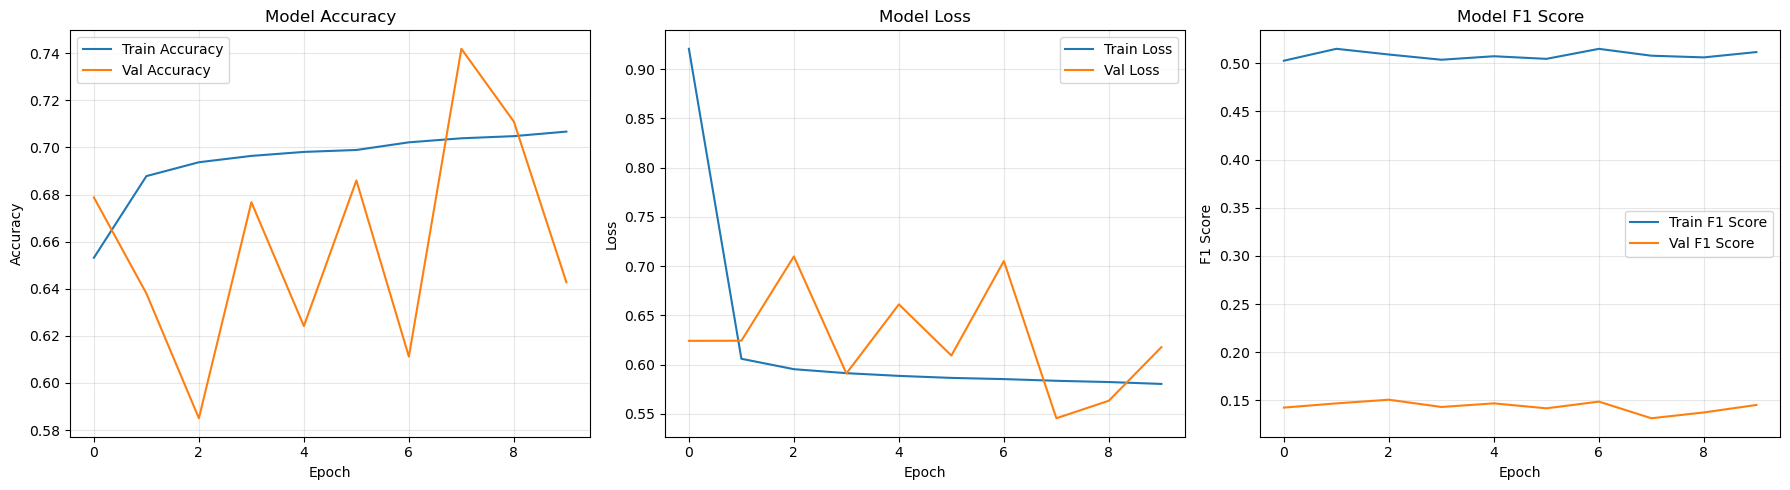

In [25]:
# Plot training history for Colin's final data
plot_training_history(history_colin_dev)

In [26]:
# Evaluate on Colin's final test set (using transformed data)
eval_results_colin_dev = model_colin_dev.evaluate(
    X_test_final_selected, Y_test_final.values.ravel(), verbose=1
)
test_loss_colin_dev, test_accuracy_colin_dev, test_f1_colin_dev = eval_results_colin_dev
print(
    f"\nColin's Final TRANSFORMED Data - Test Loss: {test_loss_colin_dev:.4f}, Test Accuracy: {test_accuracy_colin_dev:.4f}, Test F1: {test_f1_colin_dev:.4f}"
)

420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7424 - f1_score: 0.1305 - loss: 0.5416

Colin's Final TRANSFORMED Data - Test Loss: 0.5416, Test Accuracy: 0.7424, Test F1: 0.1305
420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7424 - f1_score: 0.1305 - loss: 0.5416

Colin's Final TRANSFORMED Data - Test Loss: 0.5416, Test Accuracy: 0.7424, Test F1: 0.1305


### 3.3 Compare Results: Rahil's vs Colin's Data Processing

In [27]:
# Calculate metrics for both models
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

# Predictions for Rahil's data
Y_pred_rahil_proba = model_rahil.predict(
    df_test[df_test.columns.difference(["readmitted"])]
)
Y_pred_rahil = (Y_pred_rahil_proba > 0.5).astype(int).ravel()
Y_true_rahil = df_test["readmitted"].values

# Predictions for Colin's final TRANSFORMED data
Y_pred_colin_dev_proba = model_colin_dev.predict(X_test_final_selected)
Y_pred_colin_dev = (Y_pred_colin_dev_proba > 0.5).astype(int).ravel()
Y_true_colin_dev = Y_test_final.values.ravel()

# Calculate metrics
metrics_comparison = pd.DataFrame(
    {
        "Data Source": ["Rahil's Processing", "Colin's Final Processing (Transformed)"],
        "Features": [df_train.shape[1] - 1, X_train_final_selected.shape[1]],
        "Test Accuracy": [
            accuracy_score(Y_true_rahil, Y_pred_rahil),
            accuracy_score(Y_true_colin_dev, Y_pred_colin_dev),
        ],
        "Precision": [
            precision_score(Y_true_rahil, Y_pred_rahil),
            precision_score(Y_true_colin_dev, Y_pred_colin_dev),
        ],
        "Recall": [
            recall_score(Y_true_rahil, Y_pred_rahil),
            recall_score(Y_true_colin_dev, Y_pred_colin_dev),
        ],
        "F1 Score": [
            f1_score(Y_true_rahil, Y_pred_rahil),
            f1_score(Y_true_colin_dev, Y_pred_colin_dev),
        ],
        "Test Loss": [test_loss_rahil, test_loss_colin_dev],
    }
)

print("\n" + "=" * 80)
print("TRANSFORMER MODEL COMPARISON: Rahil's vs Colin's Data Processing")
print("=" * 80)
print(metrics_comparison.to_string(index=False))
print("=" * 80)
print("\nColin's Processing Improvements:")
print("  ✓ LASSO + SHAP feature selection (25 features)")
print("  ✓ Yeo-Johnson power transformation (reduced skewness/kurtosis)")
print("  ✓ SMOTE-balanced training data (1:1 ratio)")
print("  ✓ Class weights + F1 score optimization")
print("=" * 80)

447/447 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
447/447 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

TRANSFORMER MODEL COMPARISON: Rahil's vs Colin's Data Processing
                           Data Source  Features  Test Accuracy  Precision   Recall  F1 Score  Test Loss
                    Rahil's Processing        42       0.756711   0.099928 0.223917  0.138187   0.658656
Colin's Final Processing (Transformed)        25       0.742361   0.119291 0.286182  0.168391   0.541562

Colin's Processing Improvements:
  ✓ LASSO + SHAP feature selection (25 features)
  ✓ Yeo-Johnson power transformation (reduced skewness/kurtosis)
  ✓ SMOTE-balanced training data (1:1 ratio)
  ✓ Class weights + F1 score optimization

TRANSFORMER MODEL COMPARISON: Rahil's vs Colin's Data Processing
                           Data Source  Features  Test Accuracy  Precision   Recall  F1 Score  Test Loss
                    Rahil's Processing        42 

### 3.5 Summary: Data Processing Pipeline

**Colin's Final Processing Pipeline:**

1. **Feature Selection**: 
   - Stage 1: LASSO stability selection (50 bootstrap iterations)
   - Stage 2: SHAP-based refinement → 25 most important features

2. **Data Transformation**:
   - Yeo-Johnson power transform on continuous features
   - Reduces skewness and kurtosis
   - Standardizes features for neural network training

3. **Class Imbalance Handling**:
   - SMOTE: Applied to transformed training data (1:1 class balance)
   - Class Weights: Automatically calculated and applied during training
   - F1 Score Metric: Tracks positive class performance

4. **Model Architecture**:
   - Simplified transformer design (fewer parameters)
   - Reduced complexity leveraging high-quality features
   - Binary crossentropy loss with class weights

**Key Benefits:**
- Better feature quality (reduced multicollinearity)
- Improved data distributions (reduced skewness/kurtosis)
- Balanced training (SMOTE + class weights)
- Optimized for transformer architecture

## 4. Notebook Exports

#### 4.1 Export models

In [28]:
# Export the transformer model (trained on Rahil's data) to results/
model_rahil.save("../results/transformer.h5")
print("Model saved to ../results/transformer.h5")

Model saved to ../results/transformer.h5


#### 4.2 Export visualizations

In [29]:
# Create visualizations only for combined cleaned data (which has all features)
kde_plots_combined = create_kde_plots(df_combined_final, continuous_features)
box_plots_combined = create_box_plots(df_combined_final, continuous_features)
violin_combined = create_violin_plots(df_combined_final, continuous_features)

# Save visualizations to results directory
kde_plots_combined.save("../results/kde_plots_combined.html")
box_plots_combined.save("../results/box_plots_combined.html")
violin_combined.save("../results/violin_plots_combined.html")
print("Visualizations saved successfully!")

ValueError: Unable to determine data type for the field "readmitted"; verify that the field name is not misspelled. If you are referencing a field from a transform, also confirm that the data type is specified correctly.